# 시드 문맥 감성 시각화

## 분석 목적

이 노트북의 목적은 v_2_1_seed_term_context_sentiment.ipynb에서 생성한 seed-only 문맥 감성 분석 결과를 사용해 긍정/부정/중립 문맥의 분포와 ESG 등급별 차이를 시각화하는 것이다.

주요 확인 내용은 다음과 같다.

1. 전체 코퍼스에서 긍정/부정/중립 문맥 비중이 어떻게 나타나는지 확인한다.
2. 연도별 긍정/부정/중립 문맥 비중의 변화를 확인한다.
3. ESG 등급별 긍정/부정 문맥 비중 차이를 확인한다.
4. 긍정 문맥과 부정 문맥의 관계를 산점도로 확인한다.

## 입력

- final/v_2_1_seed_term_context_sentiment_analysis.csv

## 출력

- final/v_2_5_seed_context_sentiment_ratio_summary.csv
- final/v_2_5_seed_context_sentiment_yearly_summary.csv
- final/v_2_5_seed_context_sentiment_grade_summary.csv
- final/figures/v_2_5_*.png


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

LOCAL_ROOT = Path.cwd()
ROOT_CANDIDATES = [
    Path("/content/drive/MyDrive/UD_26"),
    Path("/content/drive/My Drive/UD_26"),
    LOCAL_ROOT,
    LOCAL_ROOT.parent,
]


def first_existing(candidates, default=None):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return default if default is not None else candidates[0]


ROOT = first_existing(
    [p for p in ROOT_CANDIDATES if (p / "data").exists() or (p / "final").exists()],
    LOCAL_ROOT,
)
FINAL_DIR = ROOT / "final"
FIGURE_DIR = FINAL_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = first_existing([
    FINAL_DIR / "v_2_1_seed_term_context_sentiment_analysis.csv",
    LOCAL_ROOT / "final" / "v_2_1_seed_term_context_sentiment_analysis.csv",
    LOCAL_ROOT / "v_2_1_seed_term_context_sentiment_analysis.csv",
])

print("ROOT:", ROOT)
print("INPUT_PATH:", INPUT_PATH, "|", "OK" if INPUT_PATH.exists() else "MISSING")
print("FIGURE_DIR:", FIGURE_DIR)


ROOT: /content/drive/MyDrive/UD_26
INPUT_PATH: /content/drive/MyDrive/UD_26/final/v_2_1_seed_term_context_sentiment_analysis.csv | OK
FIGURE_DIR: /content/drive/MyDrive/UD_26/final/figures


In [2]:
df = pd.read_csv(INPUT_PATH, dtype={"stock_code": "string"}, encoding="utf-8-sig")
df["stock_code"] = df["stock_code"].astype("string").str.extract(r"(\d+)", expand=False).str.zfill(6)

for col in ["fiscal_year", "esg_year", "esg_grade_num"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "esg_year" not in df.columns:
    df["esg_year"] = df["fiscal_year"] + 1

required_cols = [
    "seed_sentence_count", "positive_seed_sentence_count", "negative_seed_sentence_count", "neutral_seed_sentence_count",
    "seed_term_context_count", "positive_seed_term_context_count", "negative_seed_term_context_count", "neutral_seed_term_context_count",
    "positive_seed_sentence_share", "negative_seed_sentence_share", "neutral_seed_sentence_share",
    "positive_seed_term_context_share", "negative_seed_term_context_share",
    "esg_grade", "esg_grade_num", "fiscal_year", "esg_year",
]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Some earlier notebooks did not persist neutral term-context share. Recompute defensively.
df["neutral_seed_term_context_share"] = df["neutral_seed_term_context_count"] / df["seed_term_context_count"].replace(0, np.nan)
df["net_seed_sentence_share"] = df["positive_seed_sentence_share"] - df["negative_seed_sentence_share"]
df["net_seed_term_context_share"] = df["positive_seed_term_context_share"] - df["negative_seed_term_context_share"]

print("df:", df.shape)
print("missing esg_grade_num:", df["esg_grade_num"].isna().sum())
display(df.groupby(["fiscal_year", "esg_year"]).size().rename("n").reset_index())
display(df.head())


df: (378, 41)
missing esg_grade_num: 0


,fiscal_year,esg_year,n
0,2022,2023,126
1,2023,2024,126
2,2024,2025,126


,stock_code,company_name,fiscal_year,esg_year,rcept_no,total_word_count,total_char_count,section_count,seed_sentence_count,positive_seed_sentence_count,negative_seed_sentence_count,neutral_seed_sentence_count,mean_seed_sentence_sentiment,unique_seed_terms_in_sentences,seed_term_context_count,seed_term_occurrence_count,positive_seed_term_context_count,negative_seed_term_context_count,neutral_seed_term_context_count,mean_seed_term_context_sentiment,unique_seed_terms_matched,positive_seed_sentence_share,negative_seed_sentence_share,neutral_seed_sentence_share,positive_seed_term_context_share,negative_seed_term_context_share,seed_sentence_per_1000_words,seed_term_context_per_1000_words,seed_term_occurrence_per_1000_words,industry,esg_grade,e_grade,s_grade,g_grade,esg_grade_num,e_grade_num,s_grade_num,g_grade_num,neutral_seed_term_context_share,net_seed_sentence_share,net_seed_term_context_share
0,000020,동화약품,2022,2023,20230315001100,7808,37953,3,35,2,2,31,0.018317,14,68,118,2,3,63,-0.000832,14,0.057143,0.057143,0.885714,0.029412,0.044118,4.482582,8.709016,15.112705,NaN,C,C,B,C,1,1,2,1,0.926471,0.000000,-0.014706
1,000020,동화약품,2023,2024,20240319000652,8065,38467,3,35,2,1,32,0.036592,13,67,114,2,2,63,0.008703,13,0.057143,0.028571,0.914286,0.029851,0.029851,4.339740,8.307502,14.135152,NaN,C,B,B,C,1,2,2,1,0.940299,0.028571,0.000000
2,000020,동화약품,2024,2025,20250318000739,8097,39259,3,37,2,0,35,0.053468,14,68,115,2,0,66,0.029093,14,0.054054,0.000000,0.945946,0.029412,0.000000,4.569594,8.398172,14.202791,NaN,C,B,C,C,1,2,1,1,0.970588,0.054054,0.029412
3,000040,KR모터스,2022,2023,20230322001182,4201,20136,3,11,1,0,10,0.090888,10,18,38,1,0,17,0.055543,10,0.090909,0.000000,0.909091,0.055556,0.000000,2.618424,4.284694,9.045465,NaN,D,D,D,D,0,0,0,0,0.944444,0.090909,0.055556
4,000040,KR모터스,2023,2024,20240321002062,4888,22402,3,11,0,1,10,-0.047889,11,16,38,0,1,15,-0.032923,11,0.000000,0.090909,0.909091,0.000000,0.062500,2.250409,3.273322,7.774141,NaN,D,D,D,D,0,0,0,0,0.937500,-0.090909,-0.062500


In [3]:
# Corpus-weighted ratio: count all relevant sentences/contexts first, then calculate ratios.
# Firm-year average ratio: calculate each firm-year ratio first, then average firms equally.

def ratio_row(data, prefix, denominator_col):
    pos_col = f"positive_{prefix}_count"
    neg_col = f"negative_{prefix}_count"
    neu_col = f"neutral_{prefix}_count"
    denom = data[denominator_col].sum()
    return pd.Series({
        "n_firm_years": len(data),
        "total_units": denom,
        "positive_count": data[pos_col].sum(),
        "negative_count": data[neg_col].sum(),
        "neutral_count": data[neu_col].sum(),
        "positive_ratio_weighted": data[pos_col].sum() / denom if denom else np.nan,
        "negative_ratio_weighted": data[neg_col].sum() / denom if denom else np.nan,
        "neutral_ratio_weighted": data[neu_col].sum() / denom if denom else np.nan,
        "positive_ratio_mean_firm": data[f"positive_{prefix}_share"].mean(),
        "negative_ratio_mean_firm": data[f"negative_{prefix}_share"].mean(),
        "neutral_ratio_mean_firm": data[f"neutral_{prefix}_share"].mean(),
    })

sentence_overall = ratio_row(df, "seed_sentence", "seed_sentence_count").to_frame().T
sentence_overall.insert(0, "unit", "sentence")
context_overall = ratio_row(df, "seed_term_context", "seed_term_context_count").to_frame().T
context_overall.insert(0, "unit", "term_context")
ratio_summary_df = pd.concat([sentence_overall, context_overall], ignore_index=True)

display(ratio_summary_df)


,unit,n_firm_years,total_units,positive_count,negative_count,neutral_count,positive_ratio_weighted,negative_ratio_weighted,neutral_ratio_weighted,positive_ratio_mean_firm,negative_ratio_mean_firm,neutral_ratio_mean_firm
0,sentence,378.0,32780.0,3483.0,1049.0,28248.0,0.106254,0.032001,0.861745,0.083938,0.029213,0.886849
1,term_context,378.0,55636.0,4552.0,1554.0,49530.0,0.081818,0.027932,0.890251,0.063339,0.023547,0.913114


In [4]:
yearly_rows = []
for fiscal_year, year_df in df.groupby("fiscal_year", dropna=True):
    esg_years = sorted(year_df["esg_year"].dropna().unique().tolist())
    esg_year = esg_years[0] if len(esg_years) == 1 else esg_years
    for unit, prefix, denominator in [
        ("sentence", "seed_sentence", "seed_sentence_count"),
        ("term_context", "seed_term_context", "seed_term_context_count"),
    ]:
        row = ratio_row(year_df, prefix, denominator)
        row["fiscal_year"] = int(fiscal_year)
        row["esg_year"] = esg_year
        row["unit"] = unit
        yearly_rows.append(row)

yearly_summary_df = pd.DataFrame(yearly_rows)[[
    "fiscal_year", "esg_year", "unit", "n_firm_years", "total_units",
    "positive_count", "negative_count", "neutral_count",
    "positive_ratio_weighted", "negative_ratio_weighted", "neutral_ratio_weighted",
    "positive_ratio_mean_firm", "negative_ratio_mean_firm", "neutral_ratio_mean_firm",
]]

display(yearly_summary_df)


,fiscal_year,esg_year,unit,n_firm_years,total_units,positive_count,negative_count,neutral_count,positive_ratio_weighted,negative_ratio_weighted,neutral_ratio_weighted,positive_ratio_mean_firm,negative_ratio_mean_firm,neutral_ratio_mean_firm
0,2022.0,2023.0,sentence,126.0,10622.0,1126.0,345.0,9151.0,0.106006,0.032480,0.861514,0.084474,0.028321,0.887205
1,2022.0,2023.0,term_context,126.0,18009.0,1464.0,530.0,16015.0,0.081293,0.029430,0.889278,0.063008,0.023595,0.913397
2,2023.0,2024.0,sentence,126.0,10941.0,1185.0,351.0,9405.0,0.108308,0.032081,0.859611,0.085038,0.029897,0.885065
3,2023.0,2024.0,term_context,126.0,18534.0,1555.0,507.0,16472.0,0.083900,0.027355,0.888745,0.064531,0.023664,0.911806
4,2024.0,2025.0,sentence,126.0,11217.0,1172.0,353.0,9692.0,0.104484,0.031470,0.864046,0.082302,0.029421,0.888278
5,2024.0,2025.0,term_context,126.0,19093.0,1533.0,517.0,17043.0,0.080291,0.027078,0.892631,0.062478,0.023384,0.914138


In [5]:
grade_rows = []
for (fiscal_year, esg_year, esg_grade), grade_df in df.groupby(["fiscal_year", "esg_year", "esg_grade"], dropna=False):
    for unit, prefix, denominator in [
        ("sentence", "seed_sentence", "seed_sentence_count"),
        ("term_context", "seed_term_context", "seed_term_context_count"),
    ]:
        row = ratio_row(grade_df, prefix, denominator)
        row["fiscal_year"] = int(fiscal_year)
        row["esg_year"] = int(esg_year) if pd.notna(esg_year) else np.nan
        row["esg_grade"] = esg_grade
        row["unit"] = unit
        grade_rows.append(row)

grade_summary_df = pd.DataFrame(grade_rows)
grade_summary_df["esg_grade_order"] = grade_summary_df["esg_grade"].map({"D": 0, "C": 1, "B": 2, "B+": 3, "A": 4, "A+": 5})
grade_summary_df = grade_summary_df.sort_values(["fiscal_year", "unit", "esg_grade_order"])

display(grade_summary_df[[
    "fiscal_year", "esg_year", "unit", "esg_grade", "n_firm_years", "total_units",
    "positive_ratio_mean_firm", "negative_ratio_mean_firm", "neutral_ratio_mean_firm",
    "positive_ratio_weighted", "negative_ratio_weighted", "neutral_ratio_weighted",
]])


,fiscal_year,esg_year,unit,esg_grade,n_firm_years,total_units,positive_ratio_mean_firm,negative_ratio_mean_firm,neutral_ratio_mean_firm,positive_ratio_weighted,negative_ratio_weighted,neutral_ratio_weighted
10,2022.0,2023.0,sentence,D,23.0,1018.0,0.055324,0.026552,0.918124,0.055010,0.028487,0.916503
8,2022.0,2023.0,sentence,C,18.0,950.0,0.050229,0.031505,0.918267,0.061053,0.037895,0.901053
4,2022.0,2023.0,sentence,B,8.0,583.0,0.078671,0.035402,0.885927,0.073756,0.037736,0.888508
6,2022.0,2023.0,sentence,B+,27.0,2327.0,0.089412,0.024605,0.885983,0.114310,0.025784,0.859905
0,2022.0,2023.0,sentence,A,43.0,4309.0,0.106123,0.027408,0.866468,0.113251,0.027617,0.859132
2,2022.0,2023.0,sentence,A+,7.0,1435.0,0.122907,0.037791,0.839302,0.149826,0.055052,0.795122
11,2022.0,2023.0,term_context,D,23.0,1570.0,0.044594,0.022250,0.933155,0.043949,0.023567,0.932484
9,2022.0,2023.0,term_context,C,18.0,1553.0,0.037943,0.025929,0.936129,0.047006,0.030264,0.922730
5,2022.0,2023.0,term_context,B,8.0,995.0,0.055445,0.030654,0.913901,0.051256,0.034171,0.914573
7,2022.0,2023.0,term_context,B+,27.0,3983.0,0.065783,0.020854,0.913364,0.086367,0.022596,0.891037


saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_overall_weighted_sentiment_ratio.png


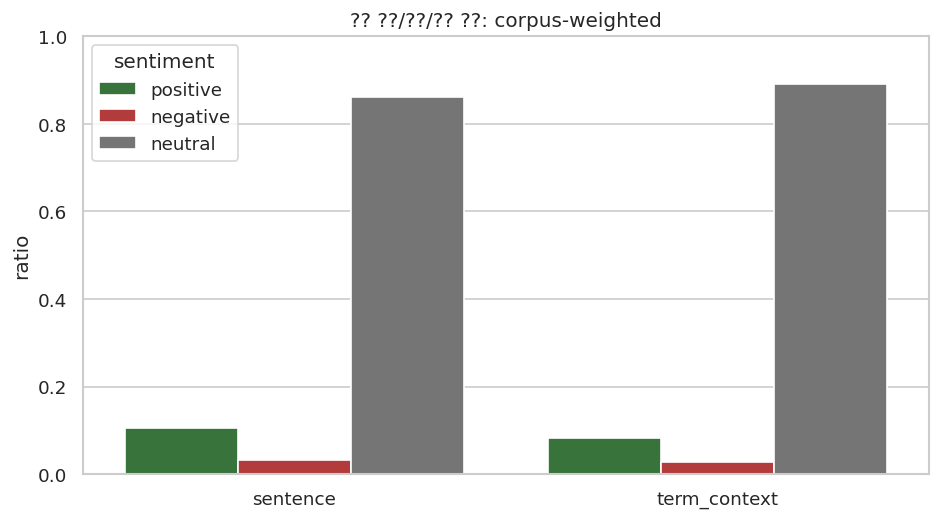

In [6]:
def savefig(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("saved:", path)

# Overall weighted composition.
plot_df = ratio_summary_df.melt(
    id_vars=["unit"],
    value_vars=["positive_ratio_weighted", "negative_ratio_weighted", "neutral_ratio_weighted"],
    var_name="sentiment",
    value_name="ratio",
)
plot_df["sentiment"] = plot_df["sentiment"].str.replace("_ratio_weighted", "", regex=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=plot_df, x="unit", y="ratio", hue="sentiment", palette={"positive": "#2E7D32", "negative": "#C62828", "neutral": "#757575"})
plt.title("?? ??/??/?? ??: corpus-weighted")
plt.xlabel("")
plt.ylabel("ratio")
plt.ylim(0, 1)
plt.legend(title="sentiment")
savefig("v_2_5_overall_weighted_sentiment_ratio.png")
plt.show()


saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_yearly_weighted_sentiment_ratio_sentence.png


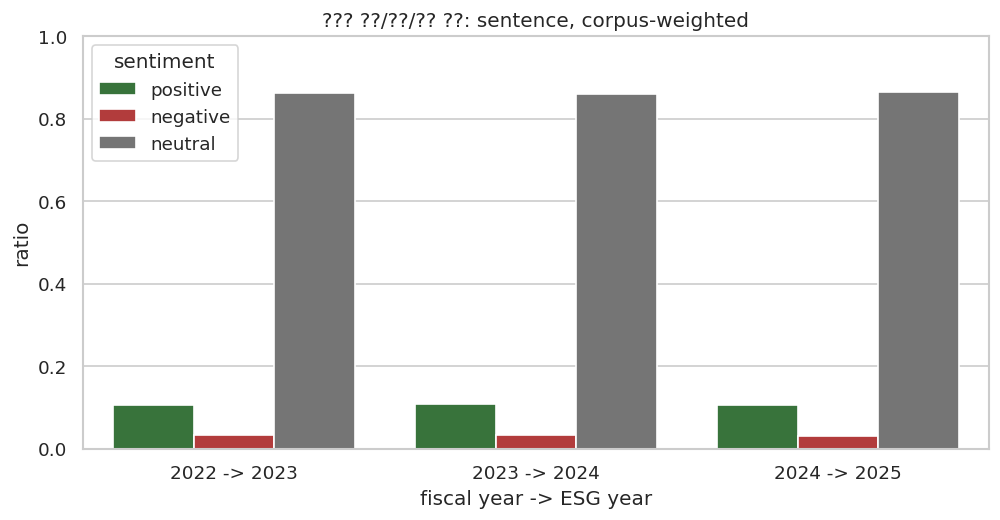

saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_yearly_weighted_sentiment_ratio_term_context.png


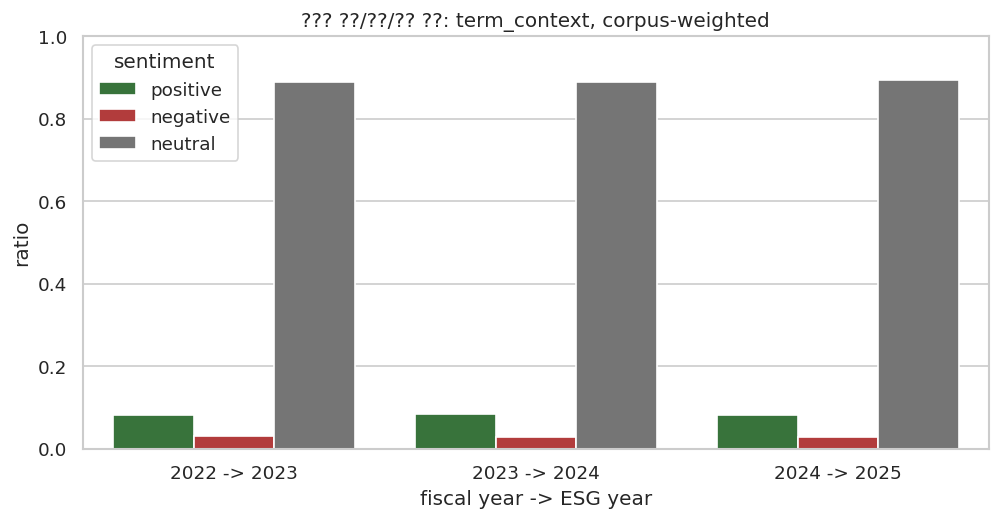

In [7]:
# Yearly weighted composition.
yearly_plot_df = yearly_summary_df.melt(
    id_vars=["fiscal_year", "esg_year", "unit"],
    value_vars=["positive_ratio_weighted", "negative_ratio_weighted", "neutral_ratio_weighted"],
    var_name="sentiment",
    value_name="ratio",
)
yearly_plot_df["sentiment"] = yearly_plot_df["sentiment"].str.replace("_ratio_weighted", "", regex=False)
yearly_plot_df["year_pair"] = yearly_plot_df["fiscal_year"].astype(int).astype(str) + " -> " + yearly_plot_df["esg_year"].astype(int).astype(str)

for unit in ["sentence", "term_context"]:
    tmp = yearly_plot_df[yearly_plot_df["unit"].eq(unit)]
    plt.figure(figsize=(8.5, 4.5))
    sns.barplot(data=tmp, x="year_pair", y="ratio", hue="sentiment", palette={"positive": "#2E7D32", "negative": "#C62828", "neutral": "#757575"})
    plt.title(f"??? ??/??/?? ??: {unit}, corpus-weighted")
    plt.xlabel("fiscal year -> ESG year")
    plt.ylabel("ratio")
    plt.ylim(0, 1)
    plt.legend(title="sentiment")
    savefig(f"v_2_5_yearly_weighted_sentiment_ratio_{unit}.png")
    plt.show()


saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_firm_year_distribution_seed_sentence.png


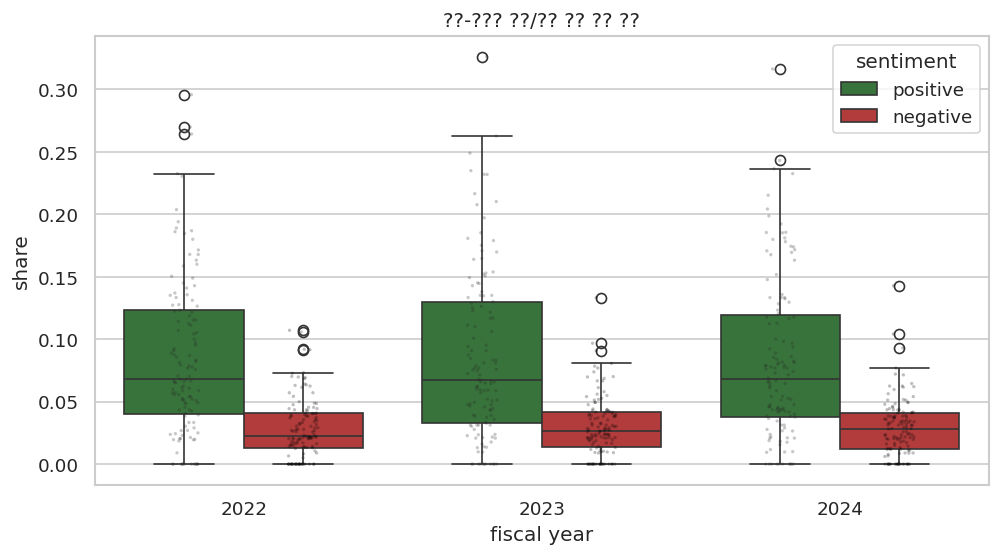

saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_firm_year_distribution_seed_term_context.png


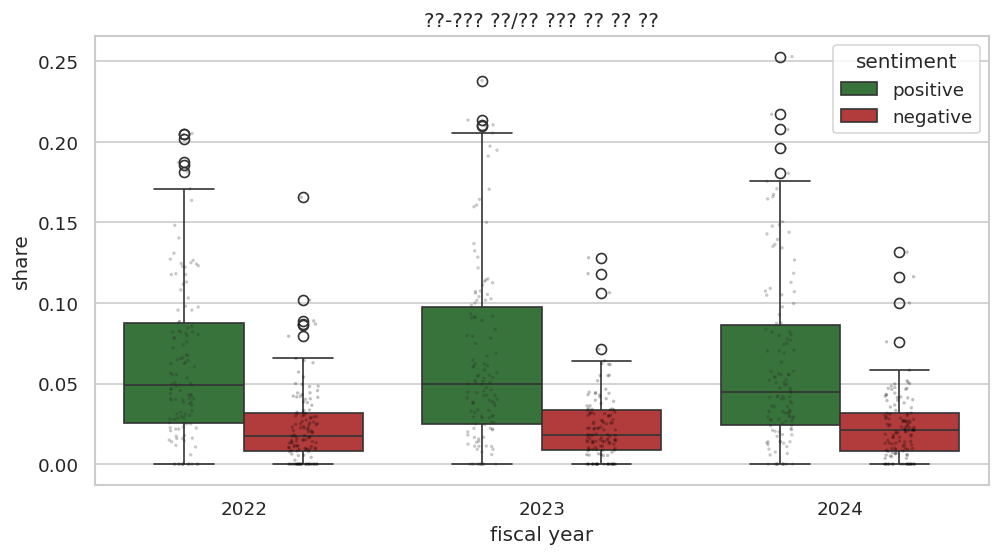

In [8]:
# Firm-year distribution by fiscal year.
dist_cols = [
    ("positive_seed_sentence_share", "negative_seed_sentence_share", "?? ??"),
    ("positive_seed_term_context_share", "negative_seed_term_context_share", "??? ?? ??"),
]

for pos_col, neg_col, title_suffix in dist_cols:
    long_df = df[["fiscal_year", pos_col, neg_col]].melt(
        id_vars=["fiscal_year"],
        value_vars=[pos_col, neg_col],
        var_name="sentiment",
        value_name="share",
    )
    long_df["sentiment"] = np.where(long_df["sentiment"].str.contains("positive"), "positive", "negative")
    plt.figure(figsize=(8.5, 4.8))
    sns.boxplot(data=long_df, x="fiscal_year", y="share", hue="sentiment", palette={"positive": "#2E7D32", "negative": "#C62828"})
    sns.stripplot(data=long_df, x="fiscal_year", y="share", hue="sentiment", dodge=True, color="black", alpha=0.25, size=2, legend=False)
    plt.title(f"??-??? ??/?? {title_suffix} ??")
    plt.xlabel("fiscal year")
    plt.ylabel("share")
    plt.legend(title="sentiment")
    savefig(f"v_2_5_firm_year_distribution_{pos_col.replace('positive_', '').replace('_share', '')}.png")
    plt.show()


saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_grade_trend_sentence.png


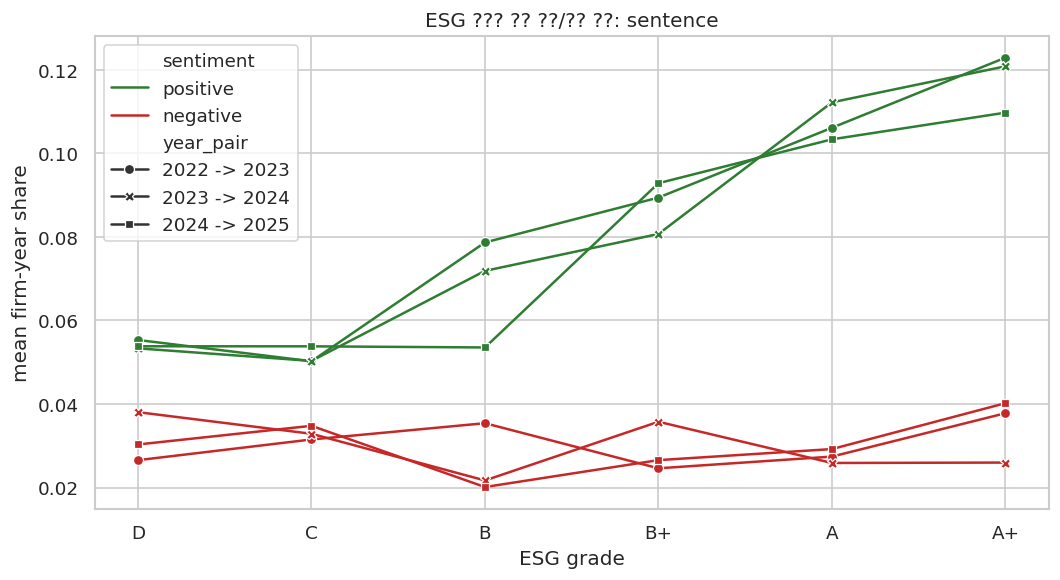

saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_grade_trend_term_context.png


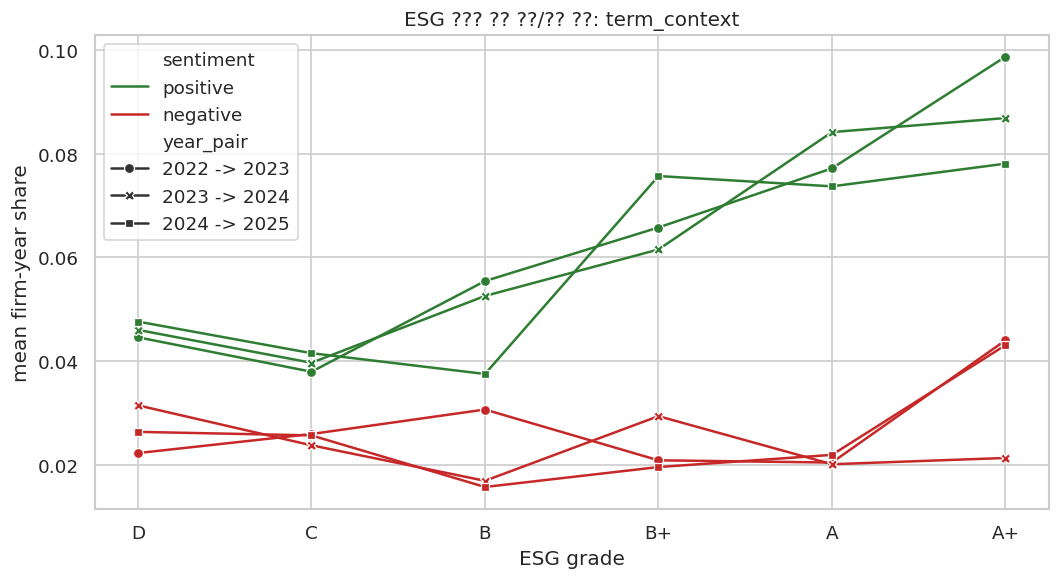

In [9]:
# ESG grade-level trend: firm-year average sentiment shares.
grade_plot_df = grade_summary_df[grade_summary_df["n_firm_years"] >= 3].copy()
grade_plot_df["year_pair"] = grade_plot_df["fiscal_year"].astype(int).astype(str) + " -> " + grade_plot_df["esg_year"].astype(int).astype(str)

for unit in ["sentence", "term_context"]:
    tmp = grade_plot_df[grade_plot_df["unit"].eq(unit)].copy()
    long_tmp = tmp.melt(
        id_vars=["year_pair", "esg_grade", "esg_grade_order", "n_firm_years"],
        value_vars=["positive_ratio_mean_firm", "negative_ratio_mean_firm"],
        var_name="sentiment",
        value_name="mean_firm_share",
    )
    long_tmp["sentiment"] = np.where(long_tmp["sentiment"].str.contains("positive"), "positive", "negative")
    plt.figure(figsize=(9, 5))
    sns.lineplot(
        data=long_tmp.sort_values("esg_grade_order"),
        x="esg_grade", y="mean_firm_share", hue="sentiment", style="year_pair",
        markers=True, dashes=False,
        palette={"positive": "#2E7D32", "negative": "#C62828"},
    )
    plt.title(f"ESG ??? ?? ??/?? ??: {unit}")
    plt.xlabel("ESG grade")
    plt.ylabel("mean firm-year share")
    plt.legend(title="")
    savefig(f"v_2_5_grade_trend_{unit}.png")
    plt.show()


saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_positive_vs_negative_scatter_sentence.png


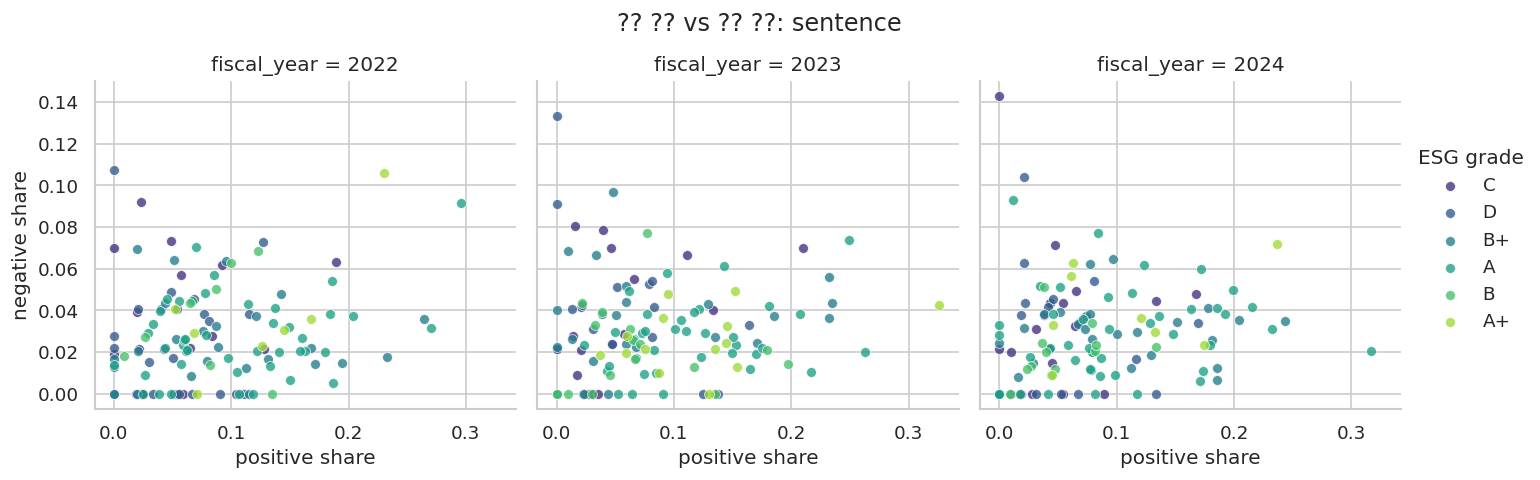

saved: /content/drive/MyDrive/UD_26/final/figures/v_2_5_positive_vs_negative_scatter_term_context.png


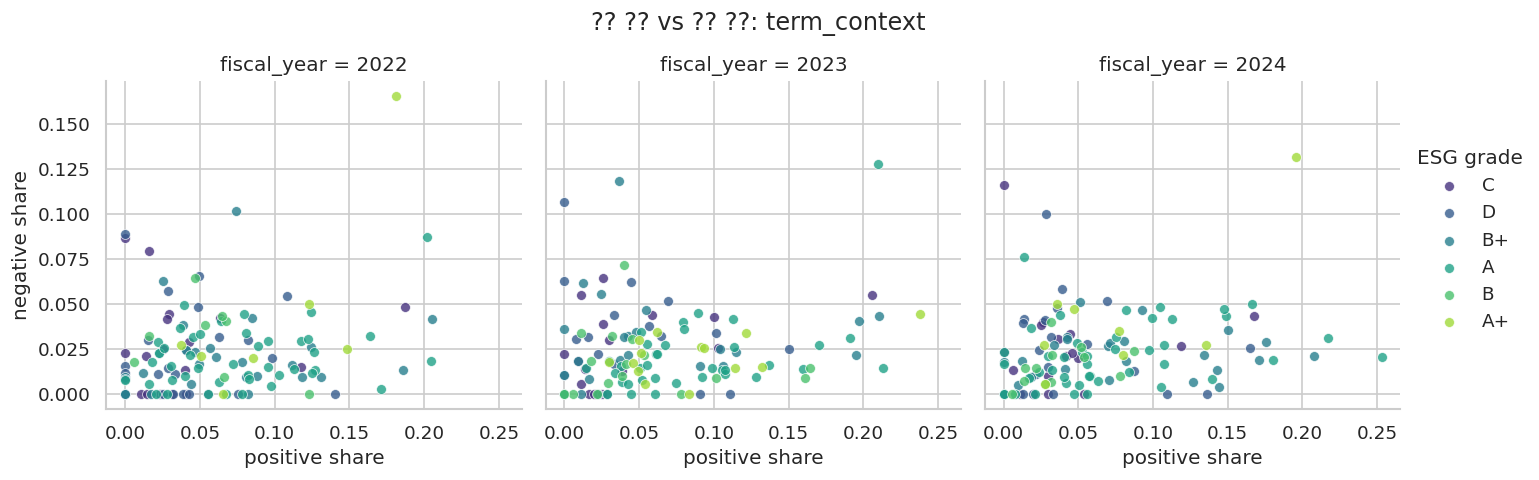

In [10]:
# Positive vs negative scatter by year, colored by ESG grade.
for unit, pos_col, neg_col in [
    ("sentence", "positive_seed_sentence_share", "negative_seed_sentence_share"),
    ("term_context", "positive_seed_term_context_share", "negative_seed_term_context_share"),
]:
    g = sns.FacetGrid(df, col="fiscal_year", hue="esg_grade", height=3.8, aspect=1.05, palette="viridis")
    g.map_dataframe(sns.scatterplot, x=pos_col, y=neg_col, alpha=0.8, s=35)
    g.add_legend(title="ESG grade")
    g.set_axis_labels("positive share", "negative share")
    g.fig.suptitle(f"?? ?? vs ?? ??: {unit}", y=1.05)
    path = FIGURE_DIR / f"v_2_5_positive_vs_negative_scatter_{unit}.png"
    g.fig.savefig(path, bbox_inches="tight", dpi=200)
    print("saved:", path)
    plt.show()


In [11]:
OUTPUT_RATIO_PATH = FINAL_DIR / "v_2_5_seed_context_sentiment_ratio_summary.csv"
OUTPUT_YEARLY_PATH = FINAL_DIR / "v_2_5_seed_context_sentiment_yearly_summary.csv"
OUTPUT_GRADE_PATH = FINAL_DIR / "v_2_5_seed_context_sentiment_grade_summary.csv"

ratio_summary_df.to_csv(OUTPUT_RATIO_PATH, index=False, encoding="utf-8-sig")
yearly_summary_df.to_csv(OUTPUT_YEARLY_PATH, index=False, encoding="utf-8-sig")
grade_summary_df.to_csv(OUTPUT_GRADE_PATH, index=False, encoding="utf-8-sig")

print("saved ratio summary:", OUTPUT_RATIO_PATH, ratio_summary_df.shape)
print("saved yearly summary:", OUTPUT_YEARLY_PATH, yearly_summary_df.shape)
print("saved grade summary:", OUTPUT_GRADE_PATH, grade_summary_df.shape)
print("figures saved in:", FIGURE_DIR)


saved ratio summary: /content/drive/MyDrive/UD_26/final/v_2_5_seed_context_sentiment_ratio_summary.csv (2, 12)
saved yearly summary: /content/drive/MyDrive/UD_26/final/v_2_5_seed_context_sentiment_yearly_summary.csv (6, 14)
saved grade summary: /content/drive/MyDrive/UD_26/final/v_2_5_seed_context_sentiment_grade_summary.csv (36, 16)
figures saved in: /content/drive/MyDrive/UD_26/final/figures
